In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("_data/importance_data.csv")

In [3]:

data["algorithm"] = data["algos"].apply(lambda x: x.upper())
# drop algos column
data = data.drop(columns=["algos"])

data["environment"] = data["envs"].apply(lambda x: x.replace("_", " ").title())
data = data.drop(columns=["envs"])

data["domain"] = data["environment"].apply(lambda x: x.split()[0])

In [4]:
data.head()

,Unnamed: 0,hp_name,hp_importance,algorithm,environment,domain
0,0,normalize_advantage,0.000127,PPO,Atari Qbert,Atari
1,1,vf_clip_eps,0.000241,PPO,Atari Qbert,Atari
2,2,minibatch_size,0.001968,PPO,Atari Qbert,Atari
3,3,gae_lambda,0.002276,PPO,Atari Qbert,Atari
4,4,clip_eps,0.006317,PPO,Atari Qbert,Atari


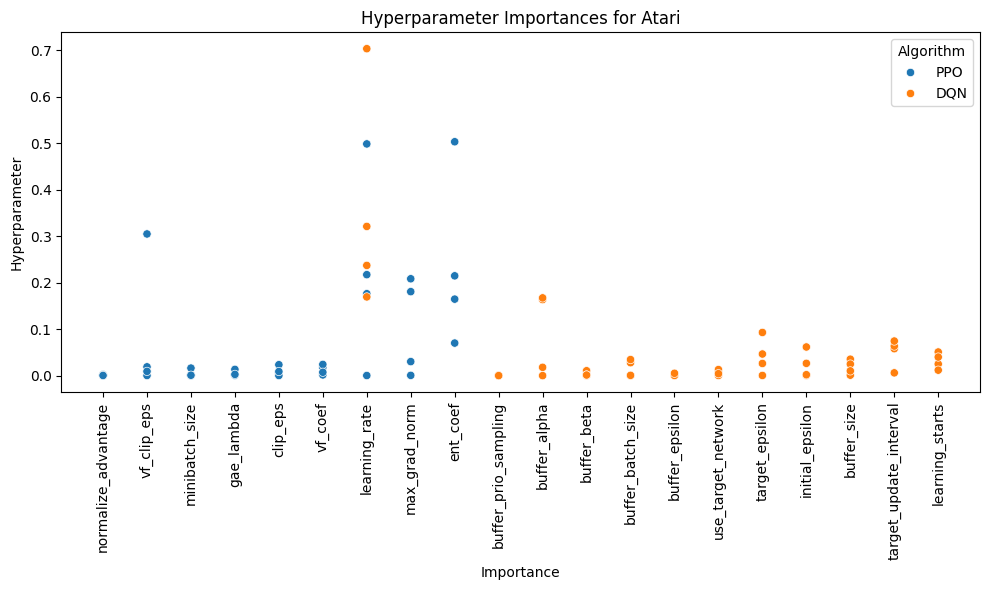

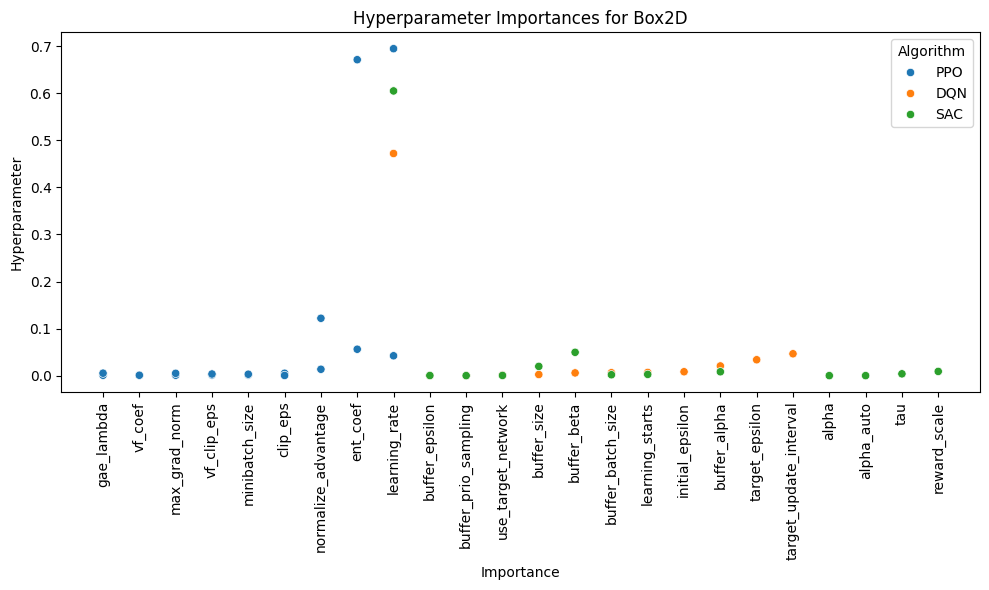

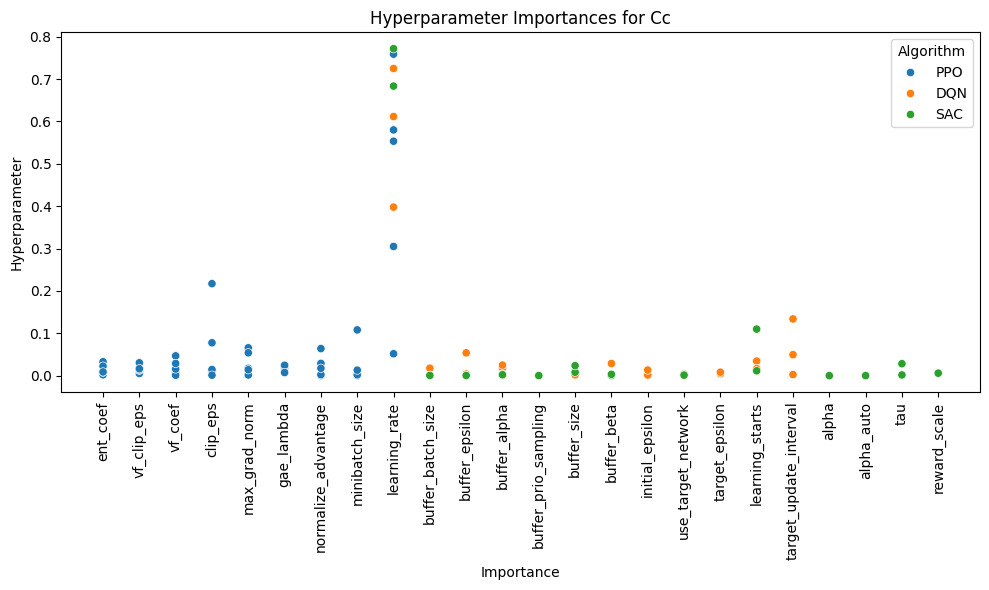

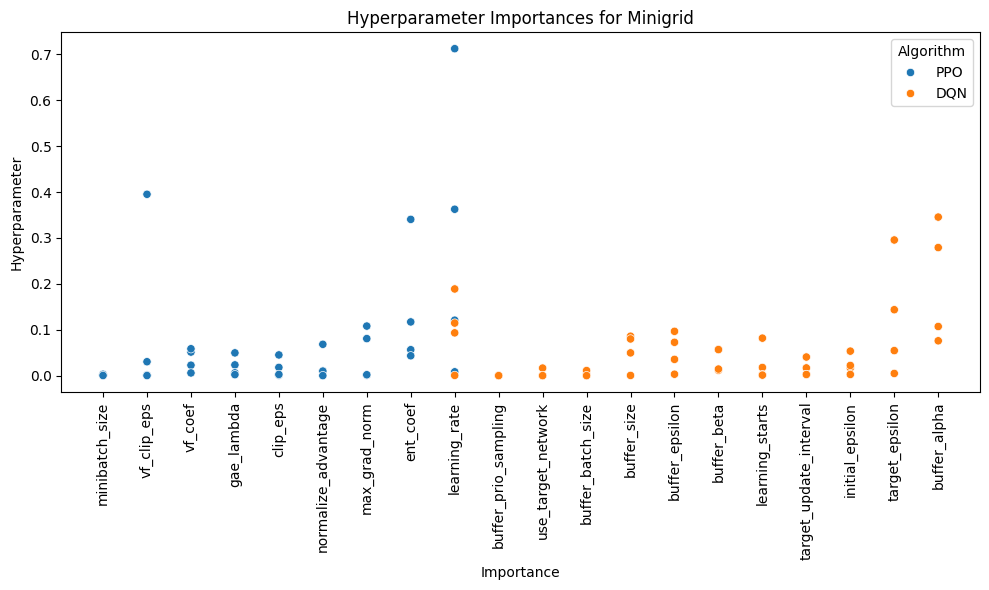

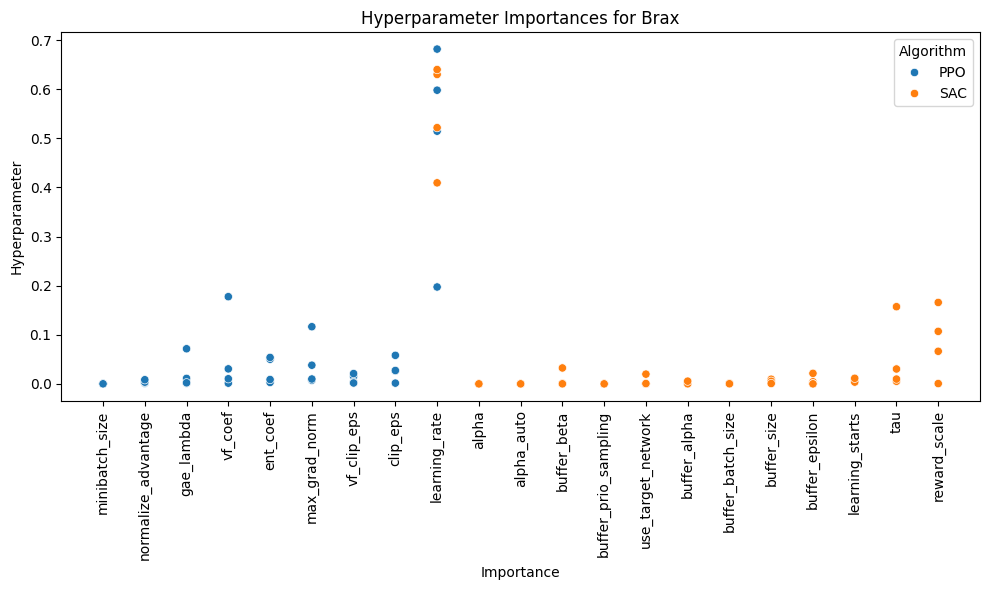

In [7]:
for domain in data["domain"].unique():
    domain_data = data[data["domain"] == domain]
    envs = domain_data["environment"].unique()
    plt.figure(figsize=(10, 6))
    sns.scatterplot(y="hp_importance", x="hp_name", hue="algorithm", data=domain_data)
    plt.title(f"Hyperparameter Importances for {domain}")
    plt.xticks(rotation=90)
    plt.xlabel("Importance")
    plt.ylabel("Hyperparameter")
    plt.legend(title="Algorithm")
    plt.tight_layout()
    plt.show()